# GNoME Structural Reproduction — Analysis Notebook

Master notebook for all post-processing and visualisation.
Each section calls the corresponding script in `analysis/` which:
- saves PNG plots to `results/`
- displays plots inline here
- prints a summary table to the console

---
**Workflow overview**

| Stage | Script | What it analyses |
|---|---|---|
| 1 — Baseline | `analysis/stage1_baseline/01_learning_curve.py` | Training convergence, epoch projections |
| 1 — Baseline | `analysis/stage1_baseline/02_wbm_eval.py` | WBM MAE, F1, confusion matrix |
| 1 — Stage A  | `analysis/stage1_stageA/01_learning_curve.py` | Stage A vs baseline convergence |
| 1 — Stage A  | `analysis/stage1_stageA/02_wbm_eval.py` | Stage A WBM metrics |
| 1 — Ensemble | `analysis/stage1_ensemble/01_ensemble_eval.py` | Ensemble WBM metrics |


In [2]:
import sys
from pathlib import Path

# Repo root: notebook lives in notebooks/, so repo root is one level up.
REPO_ROOT = Path().resolve().parent

# Add analysis directories to path 
for subdir in [
    REPO_ROOT / 'analysis' / 'stage1_baseline',
    REPO_ROOT / 'analysis' / 'stage1_stageA',
    REPO_ROOT / 'analysis' / 'stage1_ensemble',
]:
    if subdir.exists() and str(subdir) not in sys.path:
        sys.path.insert(0, str(subdir))

print(f'Repo root : {REPO_ROOT}')
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

Repo root : E:\Projects\gnome-repro-structural


In [ ]:
import torch
from torch_geometric.data import Data
from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr
from torch_geometric.data.storage import GlobalStorage, NodeStorage, EdgeStorage

torch.serialization.add_safe_globals([
    Data, DataEdgeAttr, DataTensorAttr,
    GlobalStorage, NodeStorage, EdgeStorage
])

data = torch.load("../data/processed/train.pt", weights_only=True)
print(data[0])

---
## Stage 1 — Baseline
### 1.1 Learning Curve

Source: `runs/default/history.json`  
Outputs saved to: `results/stage1_baseline/`

Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\01_learning_curve_mae.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\01_learning_curve_loss.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\01_learning_curve_zoom.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\01_summary_table.csv

  Stage 1 Baseline — Learning Curve Summary
  Best epoch         : 199  (24.42 meV/atom)
  Final epoch MAE    : 24.42 meV/atom
  Convergence epoch  : 183  (within 2% of best)
  Last-50 slope      : -0.0579 meV/epoch
  Avg wall/epoch     : 43.2 s
  --- Projections (extrapolated) ---
  Epoch  300 : ~21.92 meV   (3.6 h)
  Epoch  500 : ~20.79 meV   (6.0 h)
  Epoch 1000 : ~20.66 meV  (12.0 h)



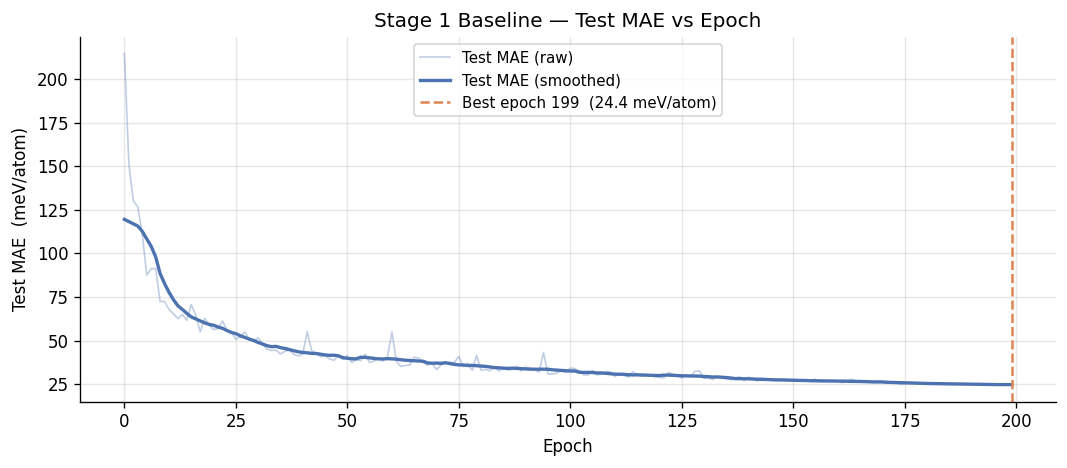

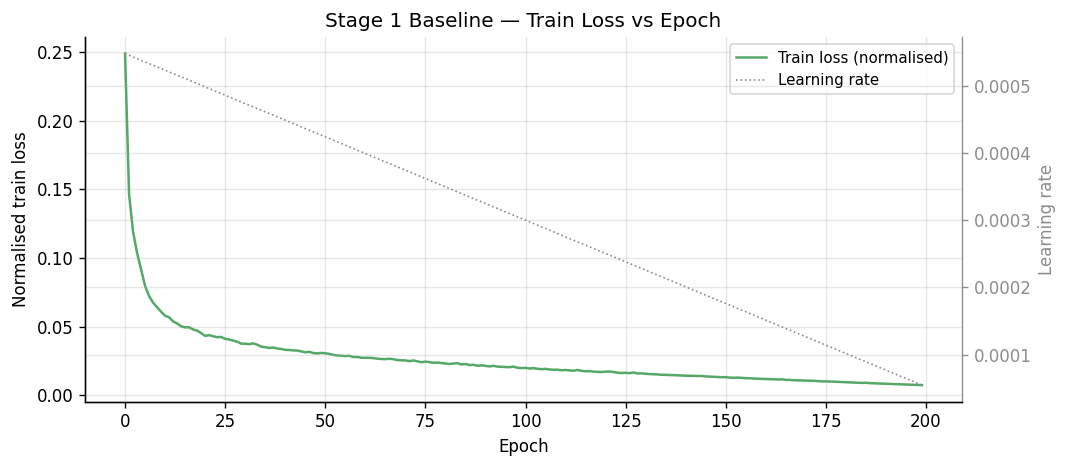

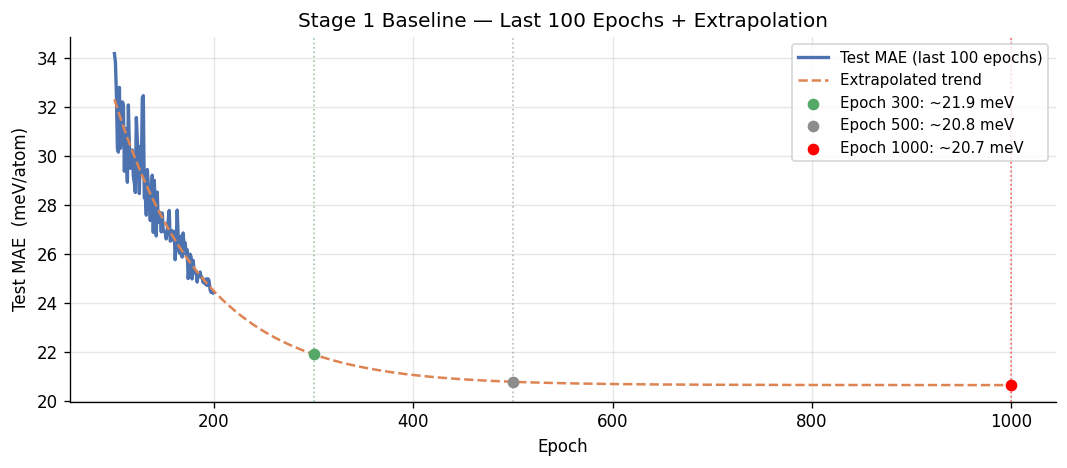

In [ ]:
import importlib, learning_curve_baseline
importlib.reload(learning_curve_baseline)

summary_baseline_lc = learning_curve_baseline.run(repo_root=REPO_ROOT, show=True)

### 1.2 WBM Evaluation Summary

Source: `runs/default/metrics_wbm.json` + `runs/default/f1_wbm.json`  
Outputs saved to: `results/stage1_baseline/`

Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\02_wbm_regression_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\02_wbm_confusion_matrix.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\02_wbm_classification_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\02_wbm_summary_table.csv

  Stage 1 Baseline — WBM Evaluation Summary
  N structures  : 256,939
  MAE           : 168.76 meV/atom
  RMSE          : 253.94 meV/atom
  Bias          : 122.48 meV/atom
  F1  (raw)     : 0.3645
  Prec(raw)     : 0.2248
  Rec (raw)     : 0.9637
  F1  (corr)    : 0.3496



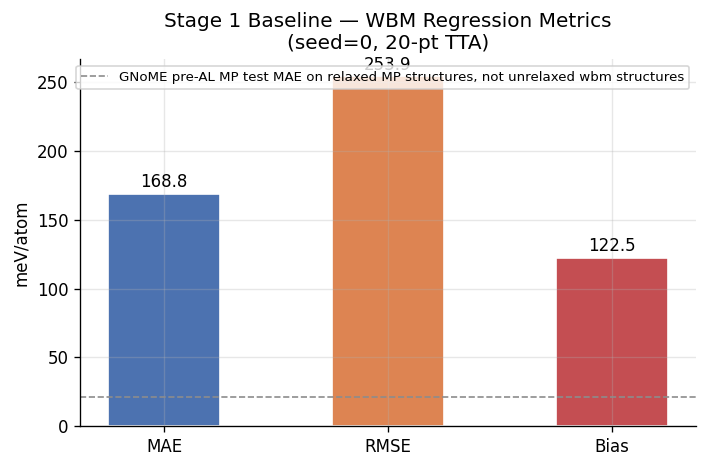

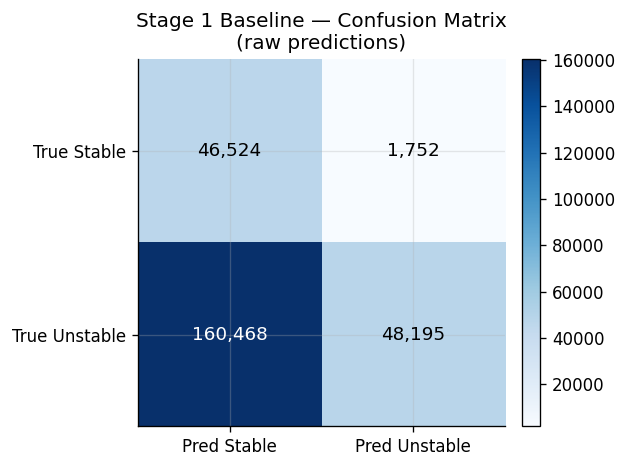

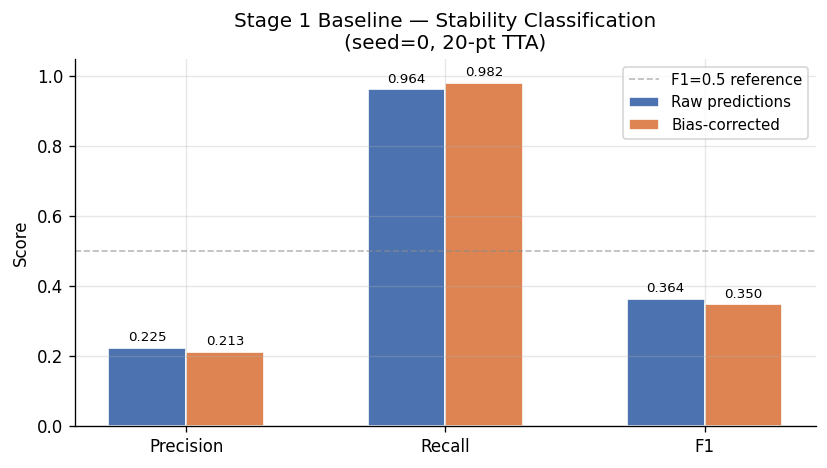

In [ ]:
import importlib, wbm_eval_baseline
importlib.reload(wbm_eval_baseline)

summary_baseline_wbm = wbm_eval_baseline.run(repo_root=REPO_ROOT, show=True)

---
### 1.3 Abaltion analysis


Compares baseline vs B1 (no adj norm), B2 (hidden=128), B3 (n_layers=2).

Source: `runs/default/`, `runs/ablation_no_norm/`, `runs/ablation_small/`, `runs/ablation_shallow/`  
Outputs saved to: `results/stage1_baseline/`

Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\03_ablation_mae_curves.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\03_ablation_bar_comparison.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\03_ablation_last50_zoom.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_baseline\03_ablation_summary_table.csv

  Stage 1 — Ablation Summary
  Run                                       Best MAE    Delta   Best Ep
  ---------------------------------------- ---------  -------  --------
  Baseline (hidden=256, layers=3, adj_norm=True)    24.42    +0.00       199
  B1: no adj norm                             25.44    +1.01       198
  B2: hidden_dim=128                          25.19    +0.77       196
  B3: n_layers=2                              25.14    +0.72       196



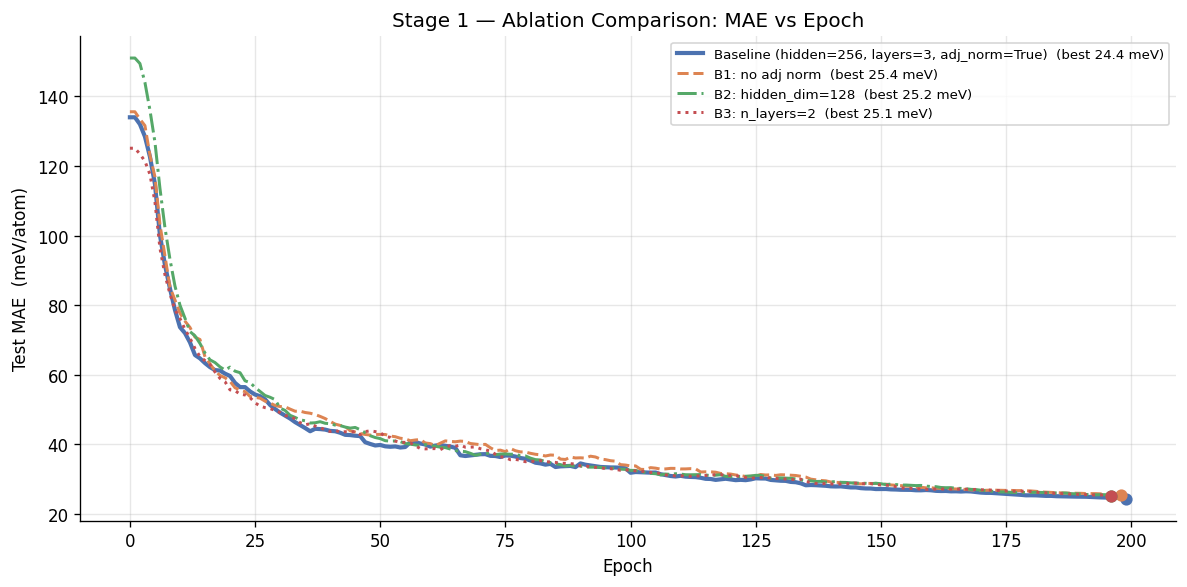

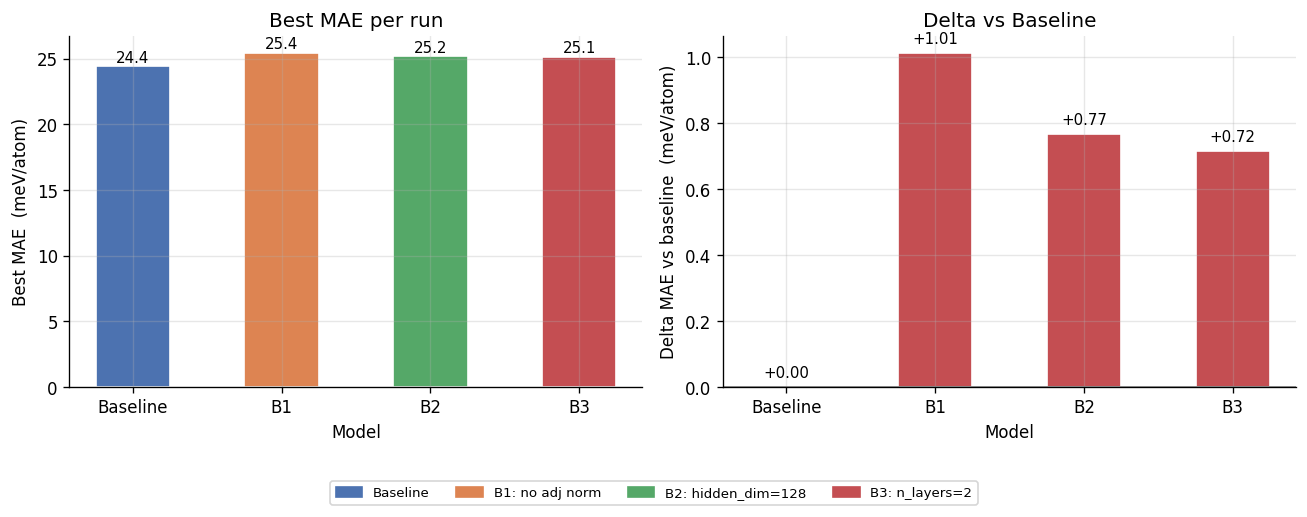

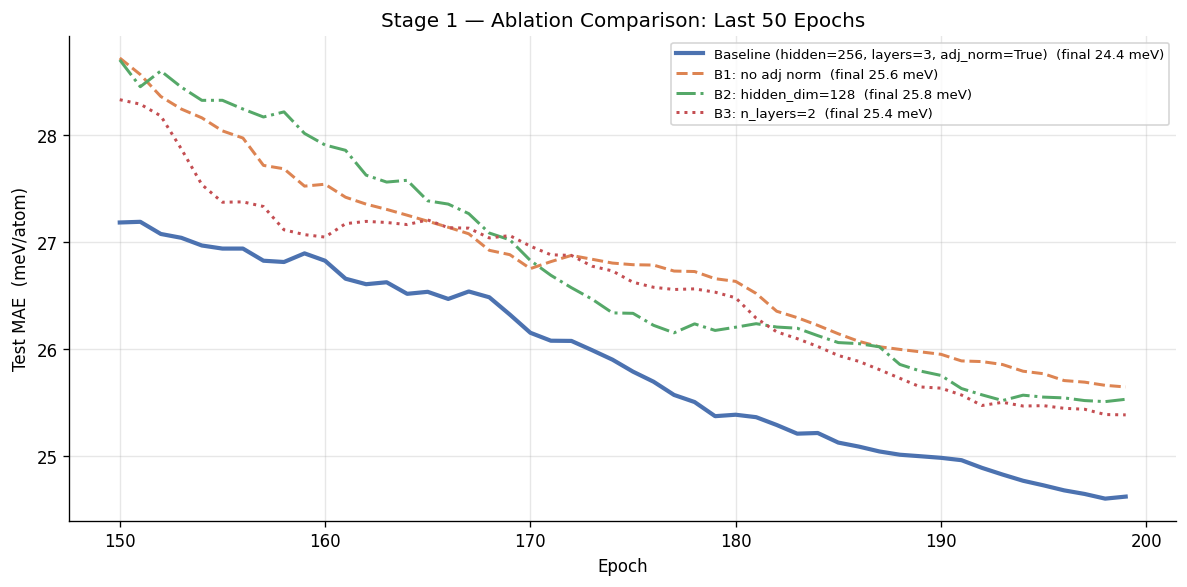

In [ ]:
# Add ablation analysis script to path if not already added by setup cell.
ablation_path = REPO_ROOT / 'analysis' / 'stage1_baseline'
if str(ablation_path) not in sys.path:
    sys.path.insert(0, str(ablation_path))

import importlib, ablation_analysis
importlib.reload(ablation_analysis)

summary_ablations = ablation_analysis.run(repo_root=REPO_ROOT, show=True)

In [ ]:
# Quick comparison table inline
import pandas as pd
if 'summary_ablations' in dir():
    display(
        pd.DataFrame(summary_ablations).T
          .sort_values('best_mae_meV')
          .style.background_gradient(subset=['best_mae_meV'], cmap='RdYlGn_r')
               .background_gradient(subset=['delta_vs_baseline_meV'], cmap='RdYlGn_r')
               .format(precision=2)
    )

,best_mae_meV,best_epoch,final_mae_meV,delta_vs_baseline_meV
"Baseline (hidden=256, layers=3, adj_norm=True)",24.42,199.00,24.42,0.00
B3: n_layers=2,25.14,196.00,25.37,0.72
B2: hidden_dim=128,25.19,196.00,25.83,0.77
B1: no adj norm,25.44,198.00,25.60,1.01


---
## Stage 1 — Stage A (longer training + EMA)
### 2.1 Learning Curve


Source: `runs/stage_a/history.json`

Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a\01_learning_curve_mae.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a\01_learning_curve_loss.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a\01_learning_curve_zoom.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a\01_ema_gain.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a\01_summary_table.csv

  Stage A (EMA-0.999) — Learning Curve Summary
  Best EMA epoch     : 386  (23.77 meV/atom)
  Final EMA MAE      : 24.07 meV/atom
  Final raw MAE      : 24.31 meV/atom
  EMA gain (final)   : 0.24 meV/atom
  Convergence epoch  : 261  (within 2% of best)
  Last-50 slope      : 0.0044 meV/epoch
  Avg wall/epoch     : 50.1 s
  --- Projections ---
  Epoch  500 : ~nan meV   (7.0 h)
  Epoch  700 : ~nan meV   (9.7 h)
  Epoch 1000 : ~nan meV  (13.9 h)



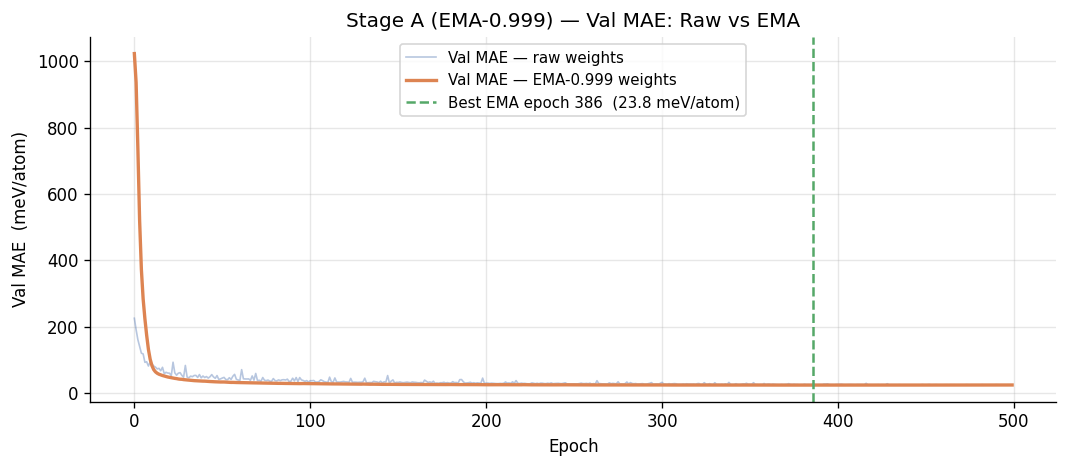

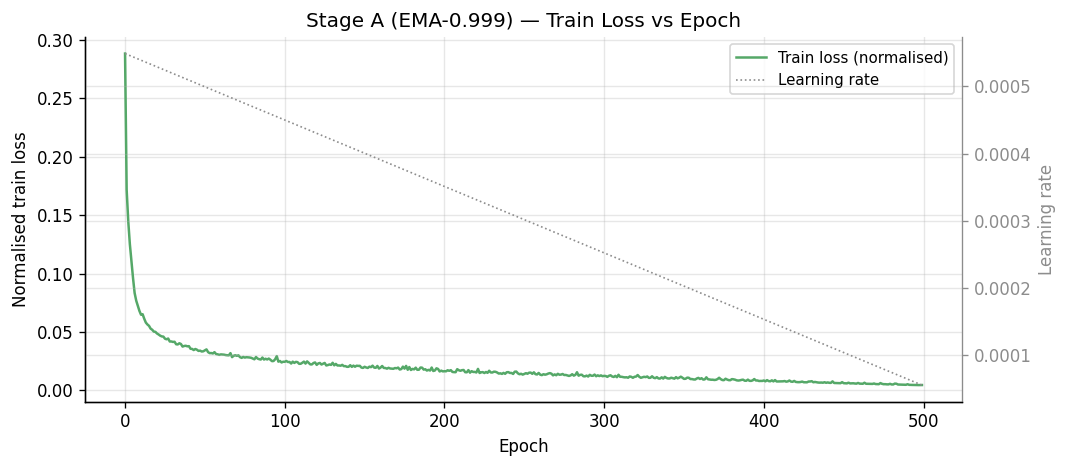

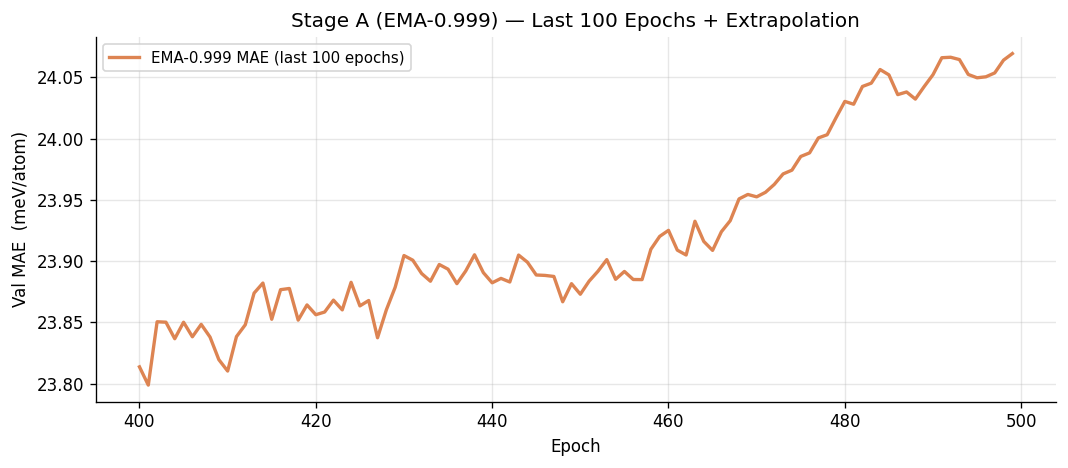

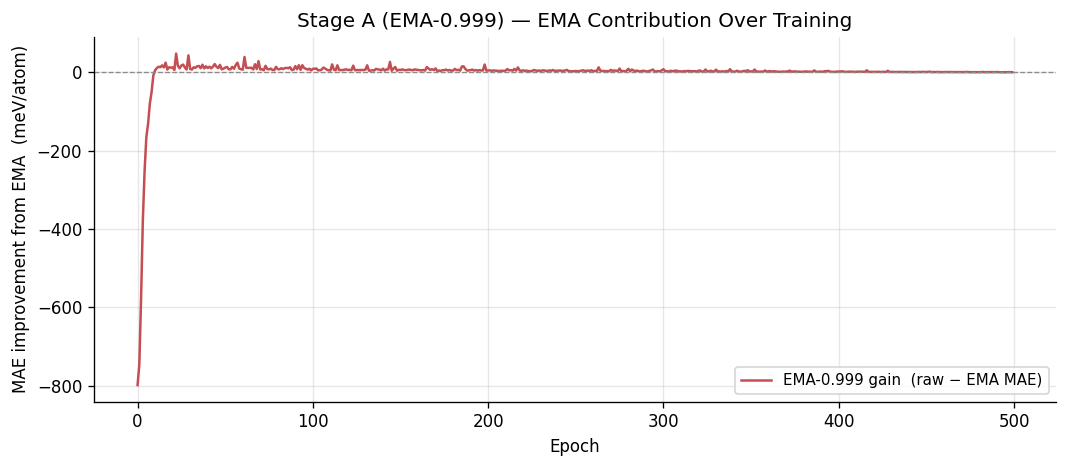

In [ ]:
stage_a_lc_path = REPO_ROOT / 'analysis' / 'stage1_stageA' / 'learning_curve_stageA.py'
if not stage_a_lc_path.exists():
    print('Stage A learning curve script not yet available.')
else:
    import importlib, sys
    sys.path.insert(0, str(stage_a_lc_path.parent))
    import learning_curve_stageA
    importlib.reload(learning_curve_stageA)
    summary_stageA_lc = learning_curve_stageA.run(repo_root=REPO_ROOT, show=True)

### 2.2 WBM Evaluation — Stage A vs Baseline

> Run this section after Stage A WBM eval completes.

Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a\02_wbm_regression_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a\02_wbm_confusion_matrix.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a\02_wbm_classification_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a\02_wbm_summary_table.csv

  Stage A (EMA-0.999) — WBM Evaluation Summary
  N structures  : 256,939
  MAE           : 159.93 meV/atom  (Δ -8.8 vs Baseline (200ep, mean-TTA))
  RMSE          : 244.88 meV/atom
  Bias          : 110.81 meV/atom  (Δ -11.7 vs Baseline (200ep, mean-TTA))
  F1  (raw)     : 0.3631  (Δ -0.0019 vs Baseline (200ep, mean-TTA))
  Prec(raw)     : 0.2234
  Rec (raw)     : 0.9697
  F1  (corr)    : 0.3494



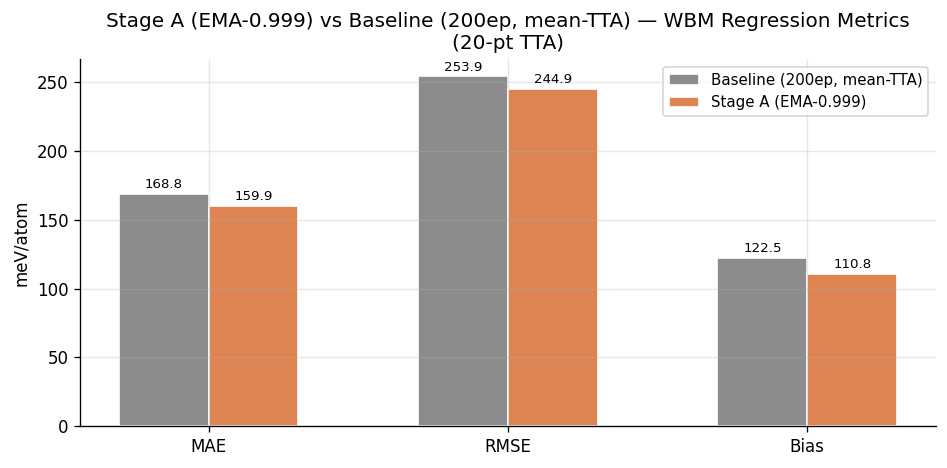

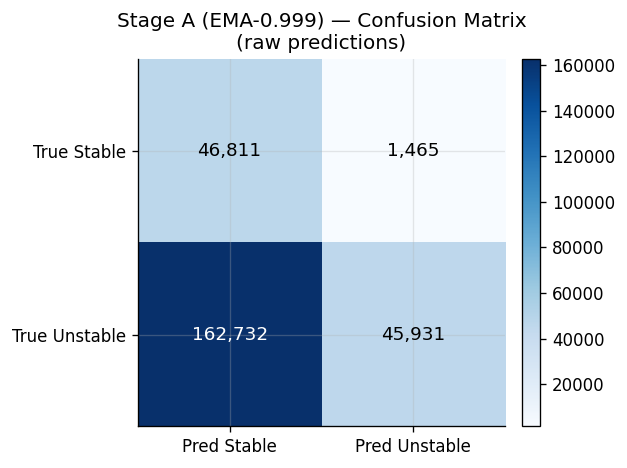

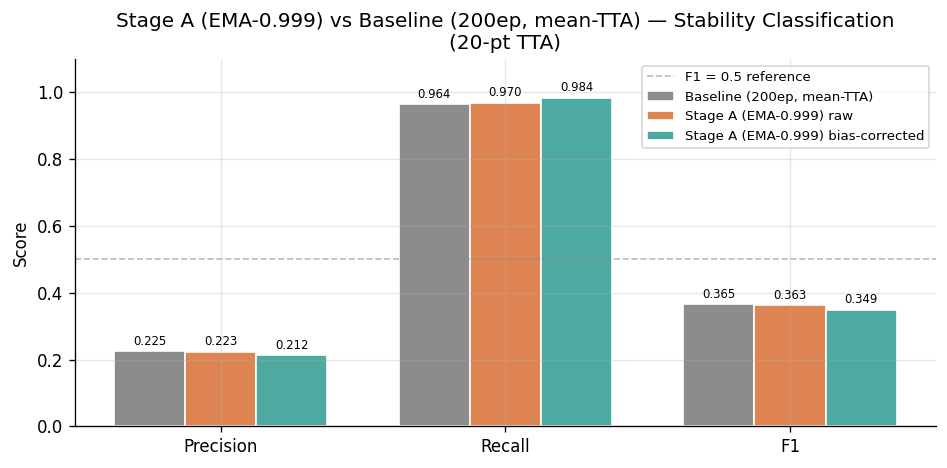

In [ ]:
stage_a_wbm_path = REPO_ROOT / 'analysis' / 'stage1_stageA' / 'wbm_eval_stageA.py'
if not stage_a_wbm_path.exists():
    print('Stage A WBM eval script not yet available.')
else:
    import importlib, wbm_eval_stageA
    importlib.reload(wbm_eval_stageA)
    summary_stageA_wbm = wbm_eval_stageA.run(repo_root=REPO_ROOT, show=True)

---
## Stage 1 — Stage A EMA-0.99

> Run this section after `stage_a_ema99` training and WBM eval complete.

Data source: `runs/stage_a_ema99/`

### 2.3  Learning Curve — EMA-0.99

Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_ema99\01_learning_curve_mae.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_ema99\01_learning_curve_loss.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_ema99\01_learning_curve_zoom.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_ema99\01_ema_gain.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_ema99\01_summary_table.csv

  Stage A (EMA-0.99) — Learning Curve Summary
  Best EMA epoch     : 382  (24.32 meV/atom)
  Final EMA MAE      : 24.40 meV/atom
  Final raw MAE      : 24.62 meV/atom
  EMA gain (final)   : 0.21 meV/atom
  Convergence epoch  : 262  (within 2% of best)
  Last-50 slope      : -0.0002 meV/epoch
  Avg wall/epoch     : 45.5 s
  --- Projections ---
  Epoch  500 : ~24.40 meV   (6.3 h)
  Epoch  700 : ~24.40 meV   (8.8 h)
  Epoch 1000 : ~24.40 meV  (12.6 h)



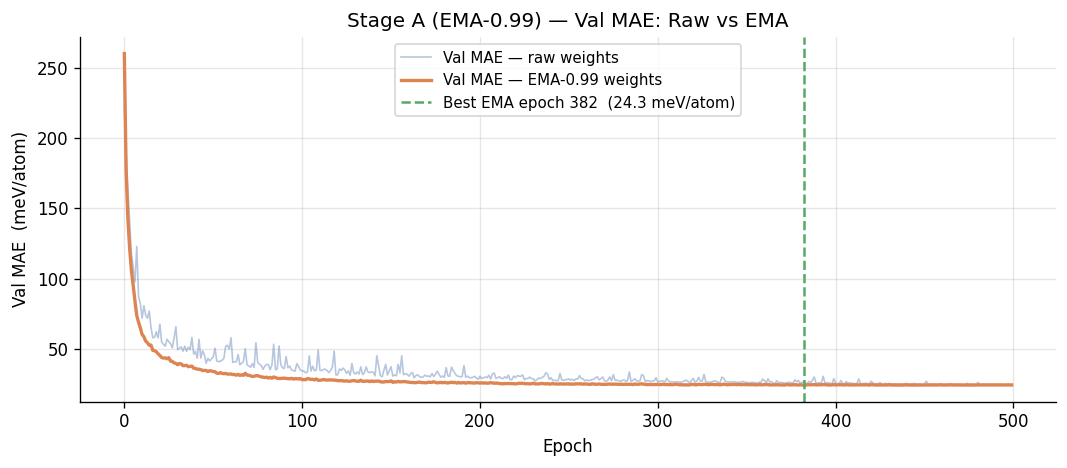

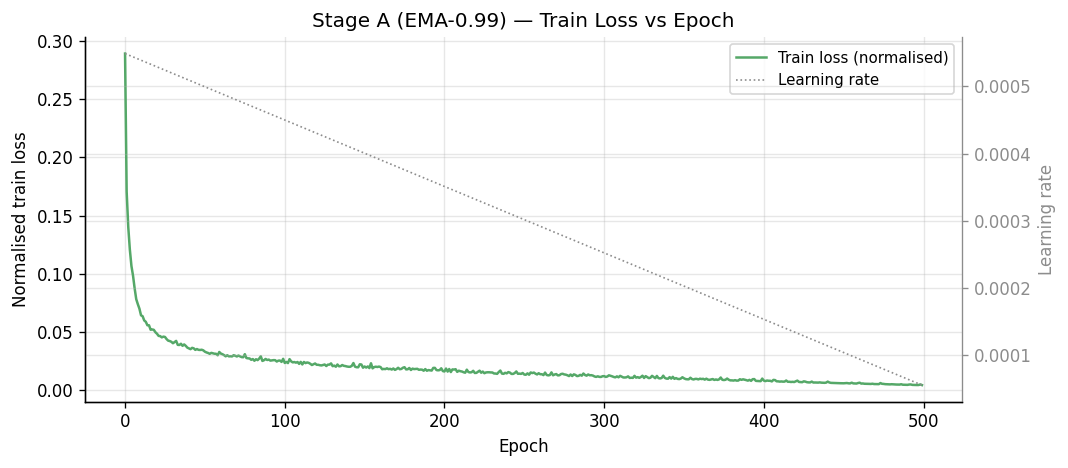

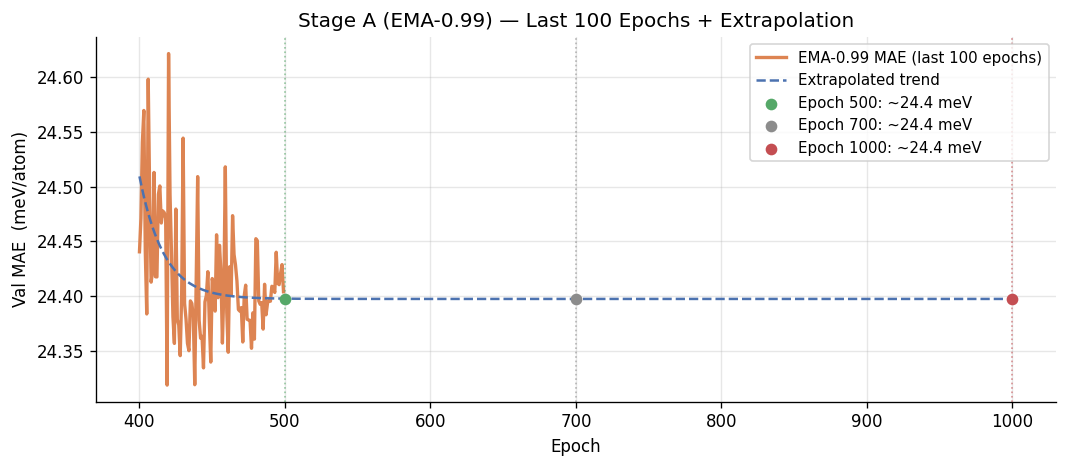

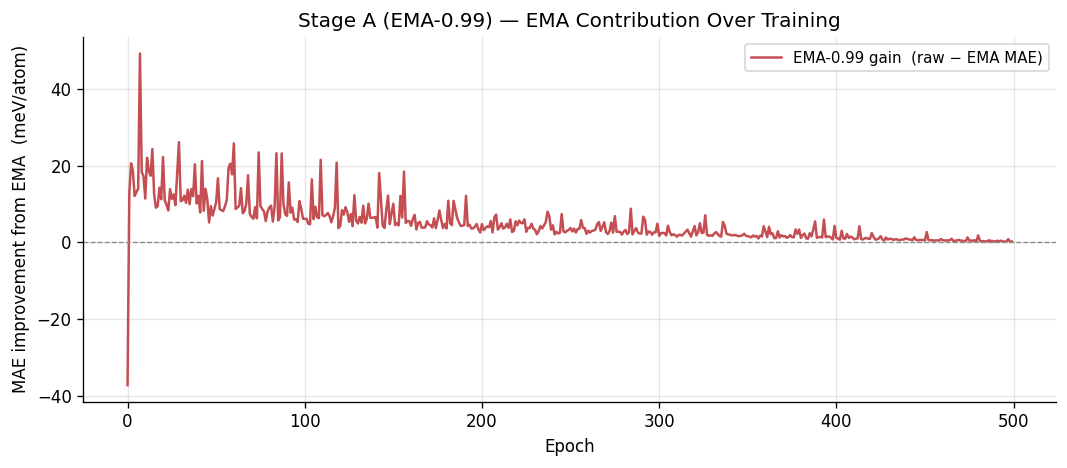

In [ ]:
import importlib, sys

lc_path = REPO_ROOT / 'analysis' / 'stage1_stageA'
if str(lc_path) not in sys.path:
    sys.path.insert(0, str(lc_path))

import learning_curve_stageA
importlib.reload(learning_curve_stageA)

summary_ema99_lc = learning_curve_stageA.run(
    repo_root = REPO_ROOT,
    run_name  = 'stage_a_ema99',
    ema_label = 'EMA-0.99',
    show      = True,
)

### 2.4  WBM Evaluation — EMA-0.99 vs EMA-0.999

Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_ema99\02_wbm_regression_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_ema99\02_wbm_confusion_matrix.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_ema99\02_wbm_classification_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_ema99\02_wbm_summary_table.csv

  Stage A (EMA-0.99) — WBM Evaluation Summary
  N structures  : 256,939
  MAE           : 170.35 meV/atom  (Δ +10.4 vs Stage A (EMA-0.999, mean-TTA))
  RMSE          : 259.20 meV/atom
  Bias          : 124.22 meV/atom  (Δ +13.4 vs Stage A (EMA-0.999, mean-TTA))
  F1  (raw)     : 0.3646  (Δ +0.0016 vs Stage A (EMA-0.999, mean-TTA))
  Prec(raw)     : 0.2249
  Rec (raw)     : 0.9627
  F1  (corr)    : 0.3486



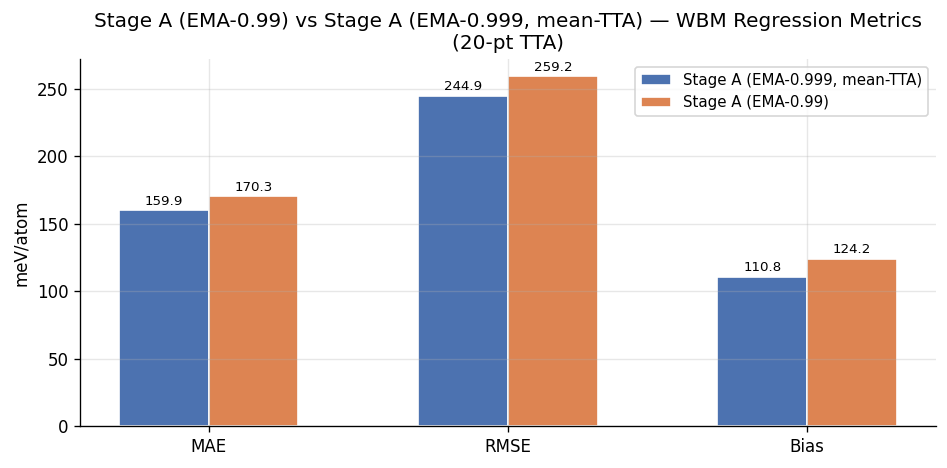

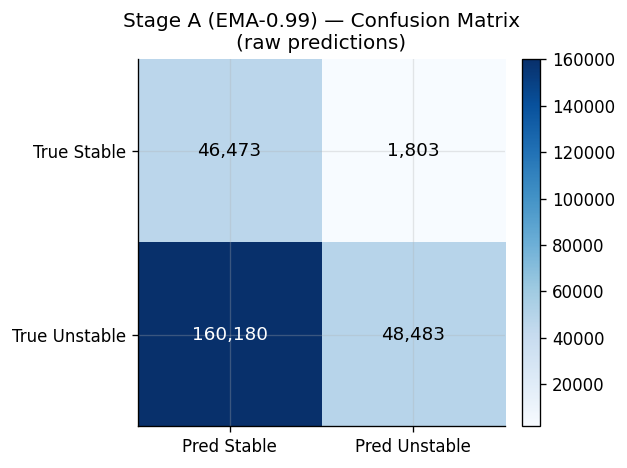

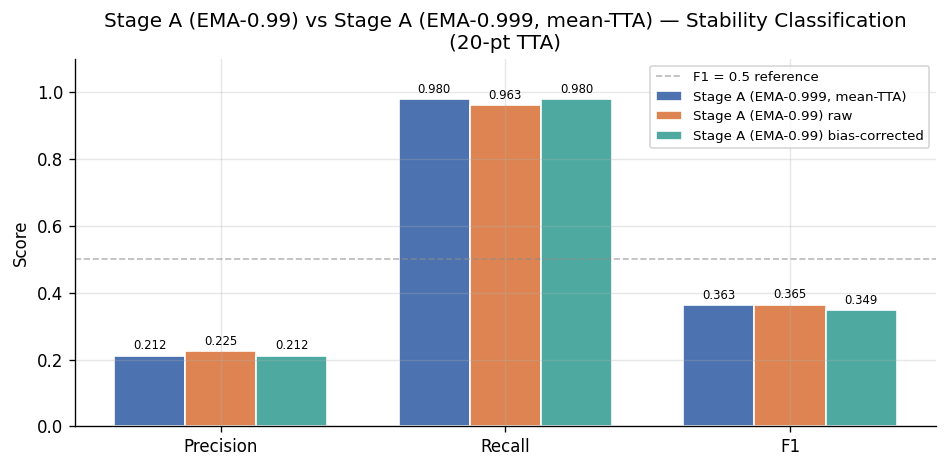

In [ ]:
import importlib, wbm_eval_stageA
importlib.reload(wbm_eval_stageA)

summary_ema99_wbm = wbm_eval_stageA.run(
    repo_root = REPO_ROOT,
    run_name  = 'stage_a_ema99',
    ema_label = 'EMA-0.99',
    show      = True,
)

### 2.5  WBM Evaluation — EMA-0.999 min-TTA

> Optional. Run only if `runs/stage_a_min_tta/` exists.

Source: `runs/stage_a_min_tta/metrics_wbm.json` + `f1_wbm.json`

Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_min_tta\02_wbm_regression_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_min_tta\02_wbm_confusion_matrix.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_min_tta\02_wbm_classification_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_stage_a_min_tta\02_wbm_summary_table.csv

  Stage A (EMA-0.999 min-TTA) — WBM Evaluation Summary
  N structures  : 256,939
  MAE           : 109.40 meV/atom  (Δ -59.4 vs Baseline (200ep, mean-TTA))
  RMSE          : 169.98 meV/atom
  Bias          : -47.65 meV/atom  (Δ -170.1 vs Baseline (200ep, mean-TTA))
  F1  (raw)     : 0.3432  (Δ -0.0218 vs Baseline (200ep, mean-TTA))
  Prec(raw)     : 0.2074
  Rec (raw)     : 0.9930
  F1  (corr)    : 0.3488



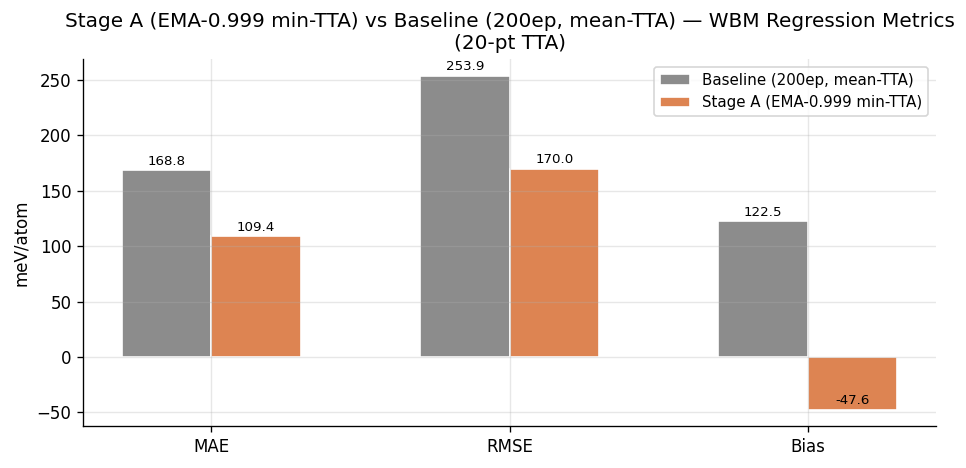

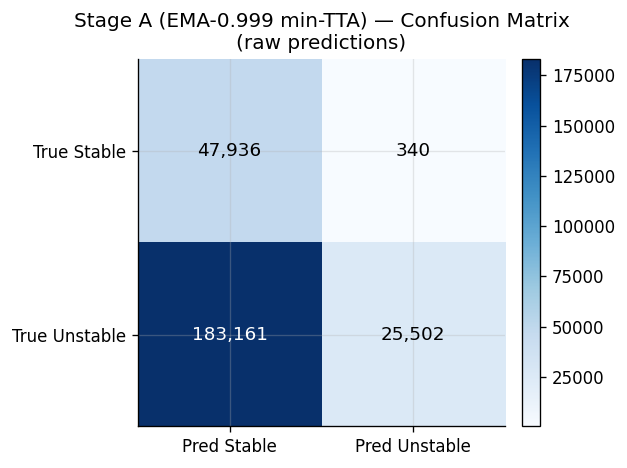

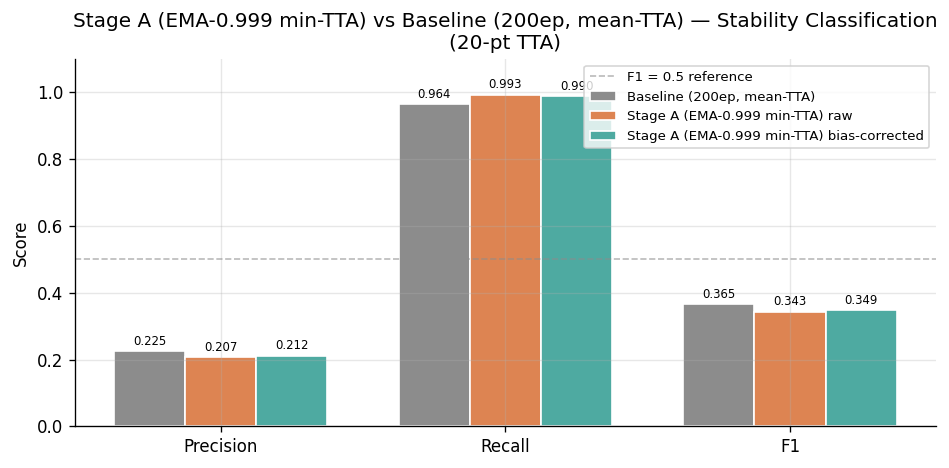

In [ ]:
import importlib, wbm_eval_stageA
importlib.reload(wbm_eval_stageA)

# min-TTA results live at runs/<run_name>/min_tta/ — pass sub_dir='min_tta'
# stage_a/min_tta is the EMA-0.999 min-TTA eval
min_tta_path = REPO_ROOT / 'runs' / 'stage_a' / 'min_tta'
if not min_tta_path.exists():
    print(f'min-TTA results not found at {min_tta_path} — skipping.')
else:
    summary_stageA_min_tta = wbm_eval_stageA.run(
        repo_root = REPO_ROOT,
        run_name  = 'stage_a',
        sub_dir   = 'min_tta',
        ema_label = 'EMA-0.999 min-TTA',
        show      = True,
    )

---
## Stage 1 — EMA Variant Comparison

Overlays EMA-0.999 and EMA-0.99 learning curves and WBM metrics.
Run only after **both** 2.1–2.2 (EMA-0.999) and 2.3–2.4 (EMA-0.99) have completed.

### 3.1  Learning Curve Comparison

E:\Projects\gnome-repro-structural\analysis\stage1_stageA\learning_curve_stageA.py:377: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: E:\Projects\gnome-repro-structural\results\stage1_stageA_compare\01_ema_variant_comparison.png

  EMA Variant — Learning Curve Delta
  Metric                       EMA-0.999  EMA-0.99        Δ
  ----------------------------  ---------  ---------  --------
  Best EMA MAE (meV)               23.77     24.32    +0.55
  Final EMA MAE (meV)              24.07     24.40    +0.33
  Best epoch                         386       382
  Convergence epoch (2%)             261       262
  Last-50 slope (meV/ep)          0.0044   -0.0002



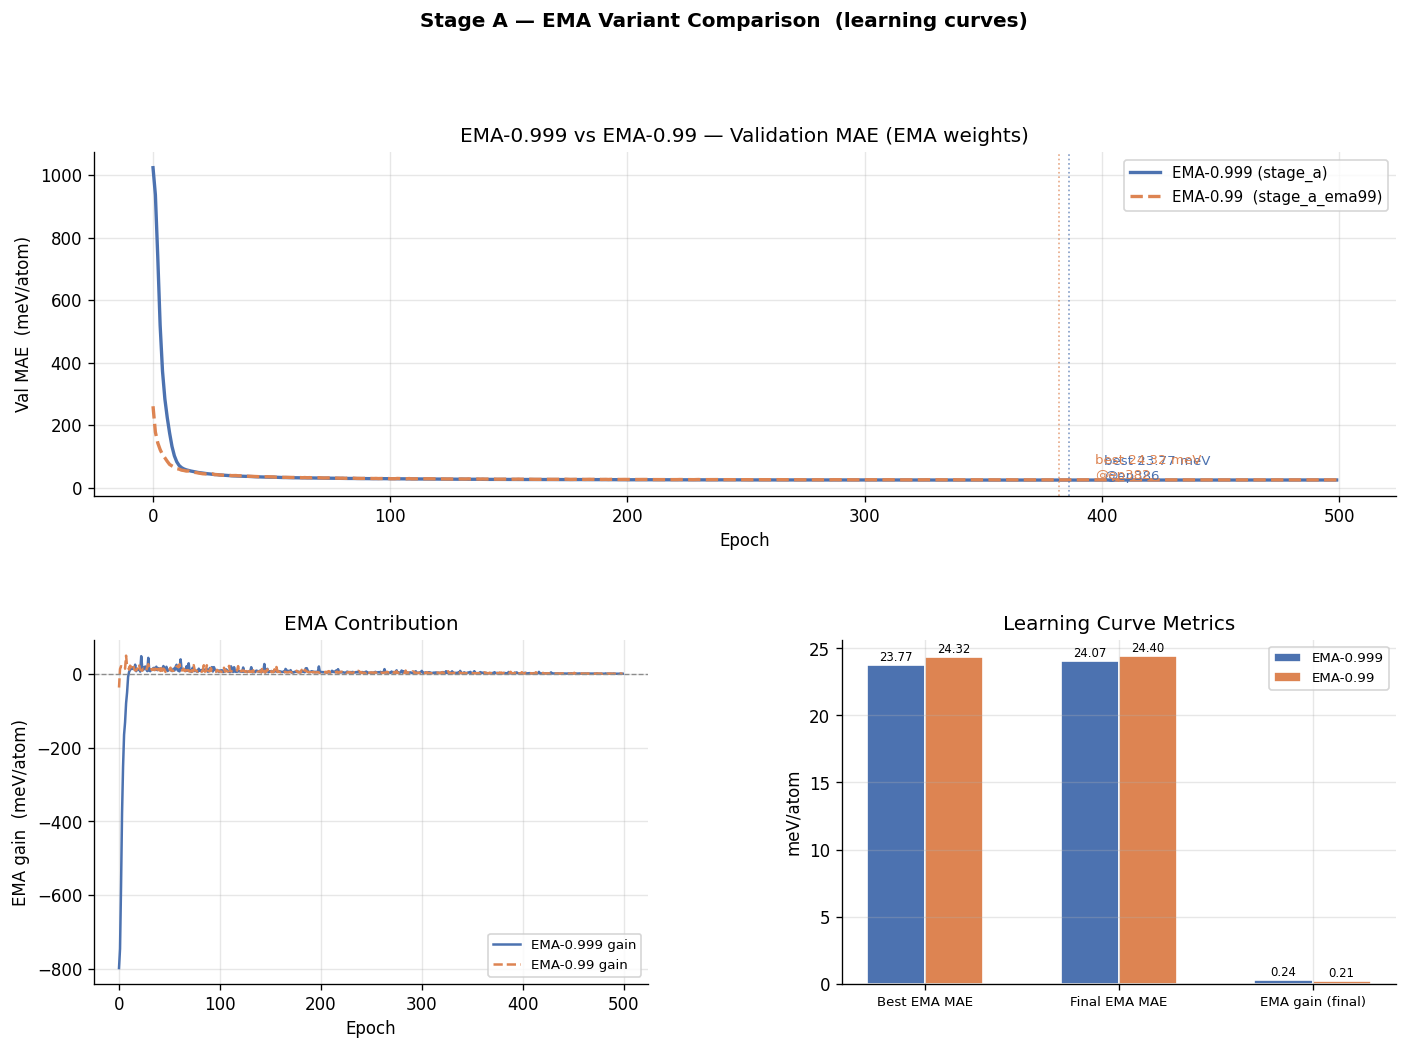

In [ ]:
import importlib, learning_curve_stageA
importlib.reload(learning_curve_stageA)

learning_curve_stageA.compare_ema_variants(
    summary_999 = summary_stageA_lc,
    summary_99  = summary_ema99_lc,
    repo_root   = REPO_ROOT,
    show        = True,
)

### 3.2  WBM Metric Comparison

In [ ]:
import importlib, wbm_eval_stageA
importlib.reload(wbm_eval_stageA)

# summary_stageA_min_tta is optional — set to None if min-TTA run not yet done
_min_tta = globals().get('summary_stageA_min_tta', None)

wbm_eval_stageA.compare_ema_variants(
    summary_999     = summary_stageA_wbm,
    summary_99      = summary_ema99_wbm,
    summary_999_min = _min_tta,
    repo_root       = REPO_ROOT,
    show            = True,
)

### 3.3  Cross-Stage Summary Table

All available runs in one table — updated to include EMA-0.99.

In [ ]:
import pandas as pd

rows = {}
try: rows['Baseline (200ep)']         = summary_baseline_wbm
except NameError: pass
try: rows['Stage A (EMA-0.999 mean)'] = summary_stageA_wbm
except NameError: pass
try: rows['Stage A (EMA-0.99 mean)']  = summary_ema99_wbm
except NameError: pass
try: rows['Stage A (EMA-0.999 min)']  = summary_stageA_min_tta
except NameError: pass
try: rows['Ensemble']                 = summary_ensemble
except NameError: pass

if rows:
    key_cols  = ['mae_meV', 'rmse_meV', 'bias_meV',
                 'f1_raw', 'precision_raw', 'recall_raw']
    available = [c for c in key_cols if c in next(iter(rows.values()))]
    compare_df = pd.DataFrame(rows).T[available].round(3)
    display(
        compare_df.style
            .background_gradient(subset=['mae_meV',  'rmse_meV'],  cmap='RdYlGn_r')
            .background_gradient(subset=['bias_meV'],              cmap='RdBu_r')
            .background_gradient(subset=['f1_raw'],                cmap='RdYlGn')
            .format(precision=3)
    )
else:
    print('No summary data available — run sections above first.')

---
## Stage 1 — Ensemble (Stage C)

Saved: E:\Projects\gnome-repro-structural\results\stage1_ensemble\03_ensemble_regression_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_ensemble\03_ensemble_confusion_matrix.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_ensemble\03_ensemble_classification_metrics.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_ensemble\03_ensemble_per_seed_mae.png
Saved: E:\Projects\gnome-repro-structural\results\stage1_ensemble\03_ensemble_summary_table.csv

  Ensemble (6 seeds, median, min-TTA) — WBM Evaluation Summary
  N structures  : 256,939
  Aggregation   : min_per_model_then_median_across_ensemble
  MAE           : 104.71 meV/atom  (Δ -4.69 vs Single model (EMA-0.999, min-TTA))
  RMSE          : 165.46 meV/atom  (Δ -4.52 vs Single model (EMA-0.999, min-TTA))
  Bias          : -47.54 meV/atom  (Δ +0.10 vs Single model (EMA-0.999, min-TTA))
  F1  (raw)     : 0.3429  (Δ -0.0003 vs Single model (EMA-0.999, min-TTA))
  Prec(raw)     : 0.2072
  Rec (r

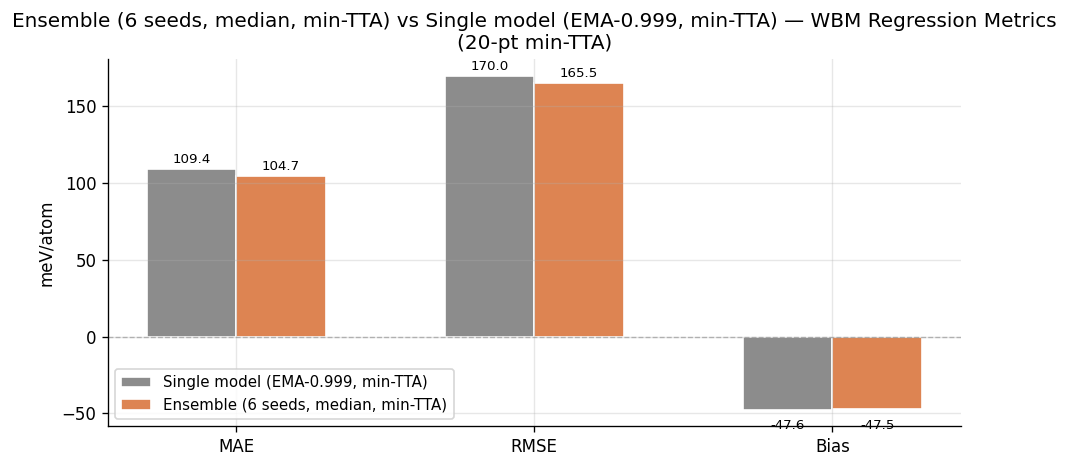

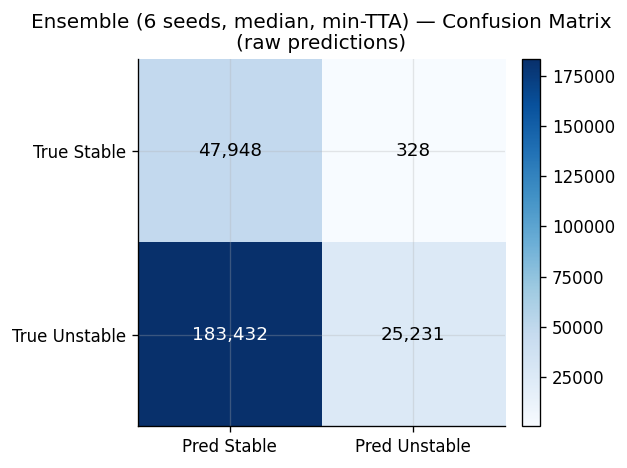

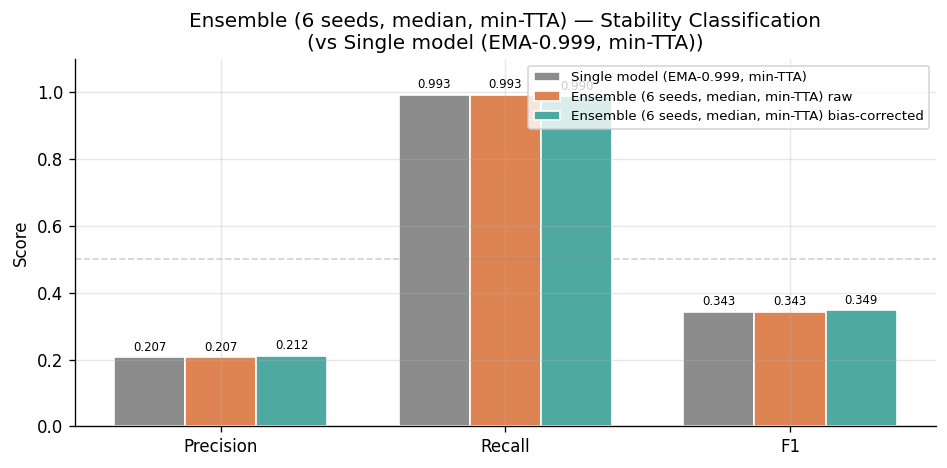

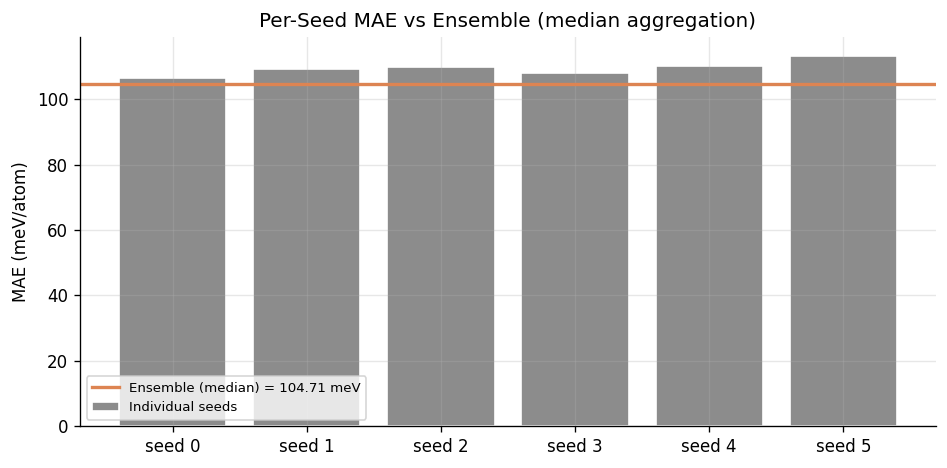

In [ ]:
ens_path = REPO_ROOT / 'analysis' / 'stage1_ensemble' / 'ensemble_eval.py'
if not ens_path.exists():
    print('Ensemble eval script not yet available.')
else:
    import importlib, ensemble_eval
    importlib.reload(ensemble_eval)
    summary_ensemble = ensemble_eval.run(repo_root=REPO_ROOT, show=True)

**For MLIP-relaxed structures**

In [ ]:
ens_path = REPO_ROOT / 'analysis' / 'stage1_ensemble' / 'ensemble_eval_relaxed.py'
if not ens_path.exists():
    print('Ensemble eval script not yet available.')
else:
    import importlib, ensemble_eval
    importlib.reload(ensemble_eval)

    summary_mace_relaxed = ensemble_eval.run(
        repo_root=REPO_ROOT,
        show=True,
        run_dir_name="ensemble_relaxed/ensemble_mace_relaxed",
        out_subdir="stage1_ensemble_mace_relaxed",
    )

    summary_chgnet_relaxed = ensemble_eval.run(
        repo_root=REPO_ROOT,
        show=True,
        run_dir_name="ensemble_relaxed/ensemble_chgnet_relaxed",
        out_subdir="stage1_ensemble_chgnet_relaxed",
    )

    import pandas as pd
    compare_cols = ["mae_meV", "rmse_meV", "bias_meV", "f1_raw", "f1_bias_corrected",
                     "delta_mae_meV_vs_ens_unrel", "delta_f1raw_vs_ens_unrel"]
    comparison = pd.DataFrame({
        "MACE-relaxed"  : {c: summary_mace_relaxed[c]   for c in compare_cols},
        "CHGNet-relaxed": {c: summary_chgnet_relaxed[c] for c in compare_cols},
    })
    print(comparison)

---
## Cross-Stage Comparison

Collects all available summary dicts and prints a comparison table.

In [ ]:
import pandas as pd

rows = {}
try: rows['Baseline'] = summary_baseline_wbm
except NameError: pass
try: rows['Stage A']  = summary_stageA_wbm
except NameError: pass
try: rows['Ensemble'] = summary_ensemble
except NameError: pass

if rows:
    compare_df = pd.DataFrame(rows).T
    key_cols = ['mae_meV', 'rmse_meV', 'bias_meV', 'f1_raw', 'precision_raw', 'recall_raw']
    available = [c for c in key_cols if c in compare_df.columns]
    display(compare_df[available].round(3))
else:
    print('No summary data available yet — run the sections above first.')

In [ ]:
import json, numpy as np
from pathlib import Path

with open(REPO_ROOT / "runs/stage_a/history.json") as f:
    h = json.load(f)

raw = np.array([e["val_mae_raw_meV"] for e in h])
ema = np.array([e["val_mae_ema_meV"] for e in h])
epochs = np.array([e["epoch"] for e in h])

print(f"Best raw MAE: {raw.min():.2f} meV at epoch {epochs[raw.argmin()]}")
print(f"Best EMA MAE: {ema.min():.2f} meV at epoch {epochs[ema.argmin()]}")
print(f"Final raw MAE: {raw[-1]:.2f} meV")
print(f"Final EMA MAE: {ema[-1]:.2f} meV")

Best raw MAE: 24.21 meV at epoch 495
Best EMA MAE: 23.77 meV at epoch 386
Final raw MAE: 24.31 meV
Final EMA MAE: 24.07 meV
